In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Plot style
%matplotlib inline

In [2]:
import matplotlib as mpl
font_names = mpl.font_manager.get_font_names()
sns.set_theme(style="whitegrid", font="Open Sans")

In [13]:
DATA_PATH = 'data/UCS-Satellite-Database 5-1-2023 (text).txt'

df = pd.read_csv(DATA_PATH, sep='\t', header=0, encoding='latin1', engine='python')

print('Data shape:', df.shape)
print('Columns:')
for i,c in enumerate(df.columns):
    print(i, repr(c))

df['is_starlink'] = df['Current Official Name of Satellite'].str.contains('Starlink', na=False, case=False)

has_starlink = True

Data shape: (7562, 68)
Columns:
0 'Name of Satellite, Alternate Names'
1 'Current Official Name of Satellite'
2 'Country/Org of UN Registry'
3 'Country of Operator/Owner'
4 'Operator/Owner'
5 'Users'
6 'Purpose'
7 'Detailed Purpose'
8 'Class of Orbit'
9 'Type of Orbit'
10 'Longitude of GEO (degrees)'
11 'Perigee (km)'
12 'Apogee (km)'
13 'Eccentricity'
14 'Inclination (degrees)'
15 'Period (minutes)'
16 'Launch Mass (kg.)'
17 ' Dry Mass (kg.) '
18 'Power (watts)'
19 'Date of Launch'
20 'Expected Lifetime (yrs.)'
21 'Contractor'
22 'Country of Contractor'
23 'Launch Site'
24 'Launch Vehicle'
25 'COSPAR Number'
26 'NORAD Number'
27 'Comments'
28 'Unnamed: 28'
29 'Source Used for Orbital Data'
30 'Source'
31 'Source.1'
32 'Source.2'
33 'Source.3'
34 'Source.4'
35 'Source.5'
36 'Source.6'
37 'Unnamed: 37'
38 'Unnamed: 38'
39 'Unnamed: 39'
40 'Unnamed: 40'
41 'Unnamed: 41'
42 'Unnamed: 42'
43 'Unnamed: 43'
44 'Unnamed: 44'
45 'Unnamed: 45'
46 'Unnamed: 46'
47 'Unnamed: 47'
48 'Unnamed: 48'


In [17]:
# Remove starlink satellites
print('Shape before removing Starlink:', df.shape)
number_satellites_total = df.shape[0]
df = df[~df['Current Official Name of Satellite'].str.contains('Starlink', na=False, case=False)]
print('Shape after removing Starlink:', df.shape)
number_satellites_no_starlink = df.shape[0]
print('Number of Starlink satellites removed:', number_satellites_total - number_satellites_no_starlink)
print('Percentage of Starlink satellites removed: {:.2f}%'.format(100 * (number_satellites_total - number_satellites_no_starlink) / number_satellites_total))
has_starlink = False

Shape before removing Starlink: (7562, 70)
Shape after removing Starlink: (3566, 70)
Number of Starlink satellites removed: 3996
Percentage of Starlink satellites removed: 52.84%


In [18]:
candidates = [c for c in df.columns if 'Launch Mass' in str(c) or 'LaunchMass' in str(c).replace(' ', '') or 'Launch mass' in str(c)]
print('Launch mass column candidates:', candidates)

if not candidates:
    raise ValueError('Could not find a Launch Mass column automatically. Check column names printed above.')

launch_col = candidates[0]
print('Using column:', repr(launch_col))

s = df[launch_col].astype(str).copy()
s = s.str.replace(',', '', regex=False).str.strip()
s_num = s.str.extract(r'([0-9]+?[0-9eE+-]*)')[0]
df['launch_mass_kg'] = pd.to_numeric(s_num, errors='coerce')

print('Parsed launch_mass_kg: non-null count =', df['launch_mass_kg'].notna().sum())
df['launch_mass_kg'].describe()

Launch mass column candidates: ['Launch Mass (kg.)']
Using column: 'Launch Mass (kg.)'
Parsed launch_mass_kg: non-null count = 3319


count     3319.000000
mean      1060.096716
std       1971.749858
min          1.000000
25%         10.000000
50%        148.000000
75%       1000.000000
max      22500.000000
Name: launch_mass_kg, dtype: float64

findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: 

Saved figure to ../media/analyses/launch_mass_histogram_no_starlink.pdf


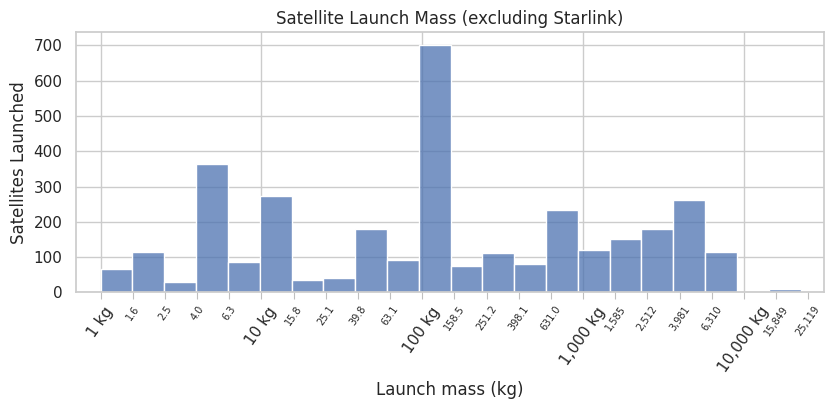

In [19]:

plt.figure(figsize=(10 * 0.85, 5 * 0.85))

if has_starlink:
    sns.histplot(df, x='launch_mass_kg', hue='is_starlink', hue_order=[1,0], binwidth=0.2, log_scale=(True, False), multiple="stack", palette=['C1', 'C0'])
else:
    sns.histplot(df, x='launch_mass_kg', binwidth=0.2, log_scale=(True, False))
ax = plt.gca()
ax.set_xscale('log')
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=[10**0.2, 10**0.4, 10**0.6, 10**0.8]))

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f} kg"))


ax.xaxis.set_minor_formatter(mticker.StrMethodFormatter("{x:,.1f}"))
ax.xaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, pos: f'' if x < 1 or x > 26e3 else f'{x:,.1f}' if x < 1000 else f'{x:,.0f}'))


ax.tick_params(axis='x', which='major', rotation=55)
ax.tick_params(axis='x', which='minor', labelsize=7, rotation=55)
ax.tick_params(axis='x', which='both', length=5, width=0.8, color='0.75', bottom=True)
ax.set_xlim(0.7, df['launch_mass_kg'].max()*1.4)

if has_starlink:
    legend = ax.get_legend()
    handles = legend.legend_handles
    ax.legend(handles, ['Starlink', 'Other Satellites'], title='')

plt.xlabel('Launch mass (kg)')
plt.ylabel('Satellites Launched')
plt.title('Satellite Launch Mass {}'.format('' if has_starlink else '(excluding Starlink)'))
plt.tight_layout()

filename = '../media/analyses/launch_mass_histogram{}.pdf'.format('' if has_starlink else '_no_starlink')
plt.savefig(filename, dpi=300)
print('Saved figure to', filename)

plt.show()


findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: Font family 'Open Sans' not found.
findfont: 

Saved figure to ../media/analyses/launch_mass_plot_no_starlink.pdf


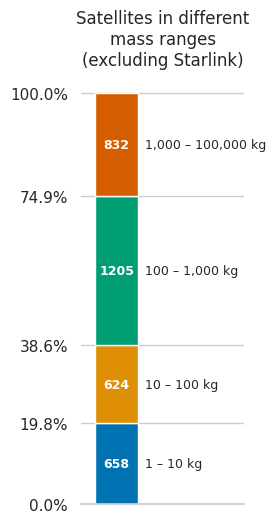

In [24]:
vals = df['launch_mass_kg'].dropna()

bins = np.logspace(0, np.ceil(np.log10(vals.max())), num=int(np.ceil(np.log10(vals.max())))+1)
bins = bins[:-1]
bins[-1] = bins[-1] * 1e1
labels = [f"{int(bins[i]):,d} – {int(bins[i+1]):,d} kg" for i in range(len(bins)-1)]

counts, _ = np.histogram(vals, bins=bins)

df_classes = pd.DataFrame({"Mass Class": labels, "Count": counts})

palette = sns.color_palette("colorblind", n_colors=len(df_classes))

plt.figure(figsize=(3 * 0.9, 6 * 0.9))
bottom = 0
total = counts.sum()
for i, (label, count) in enumerate(zip(df_classes["Mass Class"], df_classes["Count"])):
    plt.bar(0, count, bottom=bottom, color=palette[i], edgecolor='white', width=0.6)
    if count > 0:
        pct = count / total * 100
        y = bottom + count / 2
        plt.text(0, y, f"{count}", va='center', ha='center', color='white', fontsize=9, weight=700)
        plt.text(0.4, y, label, va='center', ha='left', fontsize=9)
    bottom += count

# Set y-ticks to coincide with each stacked segment boundary (cumulative counts) but show as percentages
cum = np.concatenate(([0], np.cumsum(df_classes['Count'].values)))
cum_pct = (cum / total * 100) if total > 0 else cum
# Format y-tick labels as percentages (compact)
ytick_labels = [f"{p:.1f}%" for p in cum_pct]
plt.yticks(cum, ytick_labels)
plt.xlim(-0.5, 1.8)
plt.xticks([])
plt.ylabel('')
plt.title("Satellites in different\nmass ranges{}".format("" if has_starlink else "\n(excluding Starlink)"))
sns.despine(left=True, bottom=False)
plt.tight_layout()

filename = '../media/analyses/launch_mass_plot{}.pdf'.format('' if has_starlink else '_no_starlink')
plt.savefig(filename, dpi=300)
print('Saved figure to', filename)

plt.show()